<!-- notebook-header -->
# Estatistica Inferencial e Testes de Hipotese

**Modulo:** 01 - Estatistica  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Amostragem, intervalos de confianca, testes, ANOVA, bootstrap e multiplos testes.


# Estatistica Inferencial e Testes de Hipotese

## Indice

1. [Fundamentos: Populacao, Amostra e Distribuicao Amostral](#1)
2. [Intervalos de Confianca](#2)
3. [Teste de Hipotese: Framework Completo](#3)
4. [Teste t de Student](#4)
5. [Teste Qui-Quadrado](#5)
6. [ANOVA: Comparar 3+ Grupos](#6)
7. [A/B Testing Completo](#7)
8. [Bootstrap: Estimacao Sem Pressupostos](#8)
9. [Teste de Correlacao](#9)
10. [Multiplos Testes e Correcao de Bonferroni](#10)
11. [Exercicios Praticos](#11)
12. [Erros Comuns e Armadilhas](#12)
13. [Resumo e Conexoes](#13)

## Pre-requisitos e Fio Narrativo

| Conceito | Notebook | Importancia |
|----------|----------|-------------|
| Distribuicoes (Normal, t, qui-quadrado) | 0_6, 0_7 | Fundamental |
| Probabilidade basica | 0_5 | Alta |
| Estatistica descritiva (media, variancia) | 1_1 | Fundamental |

**Tempo estimado:** 12-14 horas

**Fio narrativo:** No notebook 1_1, voce aprendeu a DESCREVER dados com medias, desvios e graficos. Mas isso so conta o que aconteceu NA SUA AMOSTRA. Agora a pergunta e: "o que posso dizer sobre o MUNDO TAREFA DO ALUNO a partir de uma amostra?" Estatistica inferencial e a ponte entre amostra e populacao. Cada tecnica aqui responde uma variacao dessa pergunta: "posso confiar nesse resultado, ou e so acaso?"

**Objetivos de aprendizado:**
- Entender estimacao pontual e intervalos de confianca
- Formular e testar hipoteses com o framework H0/H1
- Interpretar p-values corretamente (e evitar erros classicos)
- Realizar testes parametricos (t, F, qui-quadrado) e nao-parametricos
- Implementar A/B testing completo com calculo de tamanho amostral
- Usar bootstrap para estimacao livre de distribuicao
- Corrigir para multiplos testes (Bonferroni, FDR)

## Por que Estatistica Inferencial em ML?

Estatistica inferencial aparece em TODAS as etapas do pipeline de ML:

- **Validacao de modelos**: "Meu modelo A e realmente melhor que o modelo B, ou a diferenca e so acaso?" (teste t pareado)
- **Feature selection**: "Essa feature tem relacao real com o target?" (teste de correlacao, qui-quadrado)
- **A/B testing em producao**: "A nova versao do modelo melhora a metrica de negocio?" (teste de proporcoes)
- **Intervalos de confianca**: "Qual a faixa provavel de acuracia do modelo em dados novos?" (bootstrap)
- **Deteccao de drift**: "Os dados de producao mudaram em relacao ao treino?" (testes de distribuicao)
- **Hyperparameter tuning**: "Essa configuracao e estatisticamente melhor?" (ANOVA)
- **Fairness**: "O modelo trata grupos demograficos de forma diferente?" (qui-quadrado, testes de proporcoes)

Sem inferencia estatistica, voce nao tem como separar SINAL de RUIDO nos seus experimentos.

## 1. Fundamentos: Populacao, Amostra e Distribuicao Amostral

### Analogia: De Uma Amostra para o Mundo Todo

Imagine que voce quer saber a altura media de todos os brasileiros. Nao e pratico medir 215 milhoes de pessoas. Entao voce:

1. **Coleta uma amostra**: Mede 100 pessoas aleatorias
2. **Calcula a media amostral**: Obtem ~172cm
3. **Faz a pergunta crucial**: "Quanto essa amostra varia de uma coleta para outra?"

Agora imagine repetir esse experimento 100 vezes - a cada vez, coletar 100 pessoas novas e calcular a media. Voce teria 100 numeros diferentes! Alguns 171cm, alguns 173cm. Essa DISTRIBUICAO de medias e a "distribuicao amostral", e ela tem MENOS variacao que os dados brutos. Quanto maior a amostra, menor a variacao.

A confianca na inferencia estatistica vem disto: nao precisa ser perfeito em UMA amostra, porque a distribuicao amostral e mais estavel.

### Definicao Formal

- **Populacao**: Todos os elementos de interesse (tamanho N, geralmente desconhecido ou muito grande)
- **Amostra**: Subconjunto da populacao (tamanho n)
- **Parametro**: Valor fixo da populacao (mu, sigma) - queremos estimar
- **Estatistica**: Valor calculado da amostra (x_barra, s) - usamos para estimar
- **Distribuicao amostral**: Distribuicao de uma estatistica sobre muitas amostras
- **Erro padrao**: Desvio padrao da distribuicao amostral = sigma / sqrt(n)

### Por que em ML?

A distribuicao amostral e a base de TODA validacao em ML. Quando voce faz cross-validation com k folds, cada fold da uma acuracia diferente. A media dessas acuracias e uma estatistica amostral, e o desvio padrao entre folds estima o erro padrao. Se o erro padrao e grande, voce nao pode confiar que o modelo realmente tem aquela acuracia.

POPULAÇÃO: μ = 170.01 cm, σ = 10.01 cm

DISTRIBUIÇÃO AMOSTRAL DE MÉDIAS:
Média das médias: 169.68 cm
Desvio padrão das médias (erro padrão): 1.87 cm
Erro padrão teórico: σ/√n = 1.83 cm


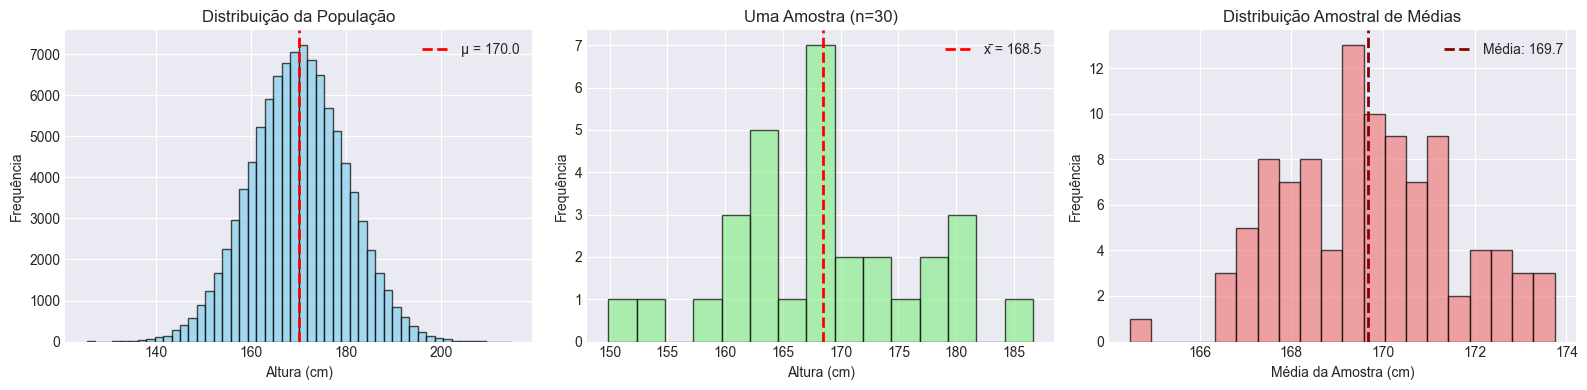

In [1]:
import numpy as np

import matplotlib.pyplot as plt


# norm, t as t_dist
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Simulação: população vs amostra
np.random.seed(42)

# População: altura em uma cidade (distribuição normal)
population = np.random.normal(loc=170, scale=10, size=100000)
print(f'POPULAÇÃO: μ = {population.mean():.2f} cm, σ = {population.std():.2f} cm')

# Tomamos várias amostras
num_samples = 100
sample_size = 30
sample_means = []

for i in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)
print(f'\nDISTRIBUIÇÃO AMOSTRAL DE MÉDIAS:')
print(f'Média das médias: {sample_means.mean():.2f} cm')
print(f'Desvio padrão das médias (erro padrão): {sample_means.std():.2f} cm')
print(f'Erro padrão teórico: σ/√n = {population.std()/np.sqrt(sample_size):.2f} cm')

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribuição da população
axes[0].hist(population, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(population.mean(), color='red', linestyle='--', linewidth=2, label=f'μ = {population.mean():.1f}')
axes[0].set_xlabel('Altura (cm)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da População')
axes[0].legend()

# Uma amostra
sample_example = sample = np.random.choice(population, size=30, replace=False)
axes[1].hist(sample_example, bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1].axvline(sample_example.mean(), color='red', linestyle='--', linewidth=2, label=f'x̄ = {sample_example.mean():.1f}')
axes[1].set_xlabel('Altura (cm)')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Uma Amostra (n={sample_size})')
axes[1].legend()

# Distribuição amostral de médias
axes[2].hist(sample_means, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
axes[2].axvline(sample_means.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Média: {sample_means.mean():.1f}')
axes[2].set_xlabel('Média da Amostra (cm)')
axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição Amostral de Médias')
axes[2].legend()

plt.tight_layout()
plt.show()

### O que observar

- A media das medias amostrais (~170) fica muito proxima da media populacional verdadeira
- O desvio padrao das medias amostrais (erro padrao) e muito MENOR que o desvio padrao da populacao
- O erro padrao empirico (~1.8) fica proximo do teorico (sigma/sqrt(n))
- A distribuicao amostral de medias tem forma de sino (Normal), mesmo se a populacao nao fosse perfeitamente normal (Teorema Central do Limite)

### O que concluir

- A distribuicao amostral "concentra" os valores em torno do parametro verdadeiro
- Amostras maiores dao erros padrao menores (mais precisao)
- O Teorema Central do Limite garante que medias amostrais tendem a Normal para n grande
- Isso e a BASE de todos os testes de hipotese e intervalos de confianca

### Conexao com outros notebooks

- **0_6 (Distribuicoes)**: A distribuicao Normal que aparece aqui e a mesma estudada la; o TCL explica POR QUE ela aparece tanto
- **0_7 (Teorema Central do Limite)**: Demonstracao formal de que medias amostrais convergem para Normal
- **1_1 (Descritiva)**: Media e desvio padrao que calculamos la agora sao usados como ESTIMADORES de parametros populacionais

## 2. Intervalos de Confianca

### Analogia: Quantificando a Incerteza

Quando calcula uma media amostral (ex: 172cm), voce sabe que nao e a media populacional verdadeira. Mas como quantificar a incerteza?

Imagine repetir o experimento 100 vezes. A cada vez, coleta amostra nova, calcula a media e constroi um intervalo. Desses 100 intervalos:
- 95 deles conteriam a verdadeira media populacional
- 5 deles nao conteriam

Esse intervalo e construido de forma que, se repetisse infinitas vezes, 95% dos intervalos conteriam o verdadeiro parametro. **Nao e** que ha 95% de chance de seu intervalo especifico conter - e mais sutil.

### Definicao Formal

IC = estimativa +/- margem_de_erro = x_barra +/- t_critico * (s / sqrt(n))

Usa-se a distribuicao t (em vez de Normal) quando nao se conhece o desvio padrao populacional. A distribuicao t tem "caudas mais pesadas" - reconhece a incerteza extra. Quanto maior a amostra, mais a t converge para Normal.

### Por que em ML?

Intervalos de confianca sao essenciais para reportar metricas de modelo. Dizer "acuracia = 85%" nao e suficiente. Dizer "acuracia = 85% +/- 3%" (IC 95%) e muito mais informativo. Tambem sao usados em A/B testing para quantificar a incerteza sobre a diferenca entre variantes.

In [2]:
# Intervalo de Confiança para a Média
print('=== INTERVALOS DE CONFIANÇA ===' )

# Dados de exemplo
heights = np.array([168, 172, 175, 170, 169, 173, 174, 171, 169, 172,
                    170, 175, 168, 172, 171, 173, 169, 170, 174, 175])

n = len(heights)
x_bar = heights.mean()
s = heights.std(ddof=1)  # desvio padrão amostral

print(f'Amostra: n={n}, x̄={x_bar:.2f} cm, s={s:.2f} cm')

# IC 95% com distribuição t (quando σ desconhecido)
alpha = 0.05
df = n - 1
t_critical = t_dist.ppf(1 - alpha/2, df)  # valor crítico
se = s / np.sqrt(n)  # erro padrão

ic_lower = x_bar - t_critical * se
ic_upper = x_bar + t_critical * se

print(f'\nIntervalo de Confiança 95% para μ (distribuição t):')
print(f'IC = [{ic_lower:.2f}, {ic_upper:.2f}] cm')
print(f'Margem de erro: ±{t_critical * se:.2f} cm')

# IC com distribuição normal (quando σ conhecido ou n grande)
z_critical = norm.ppf(1 - alpha/2)  # valor crítico z
ic_lower_z = x_bar - z_critical * se
ic_upper_z = x_bar + z_critical * se
print(f'\nIntervalo de Confiança 95% para μ (distribuição z):')
print(f'IC = [{ic_lower_z:.2f}, {ic_upper_z:.2f}] cm')

# Intervalo para proporção (exemplo: taxa de sucesso)
successes = 45  # 45 sucessos em 100 tentativas
n_prop = 100
p_hat = successes / n_prop  # proporção amostral

se_prop = np.sqrt(p_hat * (1 - p_hat) / n_prop)
ic_lower_prop = p_hat - z_critical * se_prop
ic_upper_prop = p_hat + z_critical * se_prop

print(f'\nIntervalo de Confiança 95% para p (proporção):')
print(f'Sucesso: {successes}/{n_prop} (p̂ = {p_hat:.2f})')
print(f'IC = [{ic_lower_prop:.3f}, {ic_upper_prop:.3f}] ou [{ic_lower_prop*100:.1f}%, {ic_upper_prop*100:.1f}%]')

# Efeito do tamanho amostral
print(f'\nEfeito do Tamanho Amostral:')
for sample_size in [20, 50, 100, 200]:
    se_temp = s / np.sqrt(sample_size)
    df_temp = sample_size - 1
    t_crit_temp = t_dist.ppf(1 - alpha/2, df_temp)
    margin = t_crit_temp * se_temp
    print(f'  n={sample_size}: Margem de erro = ±{margin:.3f} cm')

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Intervalo de confiança
axes[0].errorbar(1, x_bar, yerr=t_critical*se, fmt='o', markersize=10, capsize=10, capthick=2, label='IC 95%')
axes[0].axhline(170, color='red', linestyle='--', linewidth=2, alpha=0.5, label='μ (verdadeira)')
axes[0].set_xlim(0.5, 1.5)
axes[0].set_ylim(168, 173)
axes[0].set_ylabel('Altura (cm)')
axes[0].set_title('Intervalo de Confiança para a Média')
axes[0].set_xticks([])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribuição t vs Normal
x = np.linspace(-4, 4, 100)
axes[1].plot(x, t_dist.pdf(x, df), label=f't (df={df})', linewidth=2)
axes[1].plot(x, norm.pdf(x, 0, 1), label='Normal padrão', linewidth=2)
axes[1].fill_between(x, 0, norm.pdf(x, 0, 1), where=(x < -z_critical) | (x > z_critical), alpha=0.3, label='Região crítica (α=0.05)')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Densidade')
axes[1].set_title('Distribuição t vs Normal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== INTERVALOS DE CONFIANÇA ===
Amostra: n=20, x̄=171.50 cm, s=2.35 cm


NameError: name 't_dist' is not defined

### O que observar

- O IC 95% com distribuicao t e ligeiramente mais largo que com distribuicao z (caudas mais pesadas)
- A margem de erro DIMINUI conforme n cresce: n=20 tem margem ~1.1cm, n=200 tem ~0.35cm
- O IC para proporcao (45/100) vai de ~35% a 55% - bastante largo com n=100
- No grafico da distribuicao t vs Normal, as caudas da t sao visivelmente mais pesadas com df=19

### O que concluir

- Para amostras pequenas (n < 30), usar distribuicao t faz diferenca real
- Dobrar o tamanho amostral reduz a margem de erro por fator de sqrt(2) ≈ 1.41
- Intervalos de confianca para proporcoes requerem amostras grandes para serem uteis
- A escolha entre z e t nao e "preferencia" - depende se sigma e conhecido (quase nunca) ou nao

### Conexao com outros notebooks

- **1_1 (Descritiva)**: O desvio padrao amostral (s) calculado la alimenta diretamente o calculo do IC
- **0_6 (Distribuicoes)**: A distribuicao t-Student e a Normal padrao aparecem aqui como base dos ICs
- **1_4 (Regressao)**: ICs para coeficientes de regressao usam exatamente essa mesma logica

## 3. Teste de Hipotese: Framework Completo

### Analogia: Prova por Contradicao

Os testes de hipotese usam uma logica contra-intuitiva chamada "prova por contradicao":

1. **Comeca assumindo H0 (hipotese nula)**: "Nada aconteceu, o efeito e zero, a moeda e justa"
2. **Calcula a probabilidade** de ver seus dados DADO que H0 e verdadeira
3. **Se essa probabilidade e muito baixa** (p < 0.05), conclui: "isso seria muito improvavel se nada tivesse acontecido, logo rejeito que nada aconteceu"

**O que e o p-value?** Nao e a probabilidade de sua hipotese ser verdadeira. E a probabilidade de ver dados TAO EXTREMOS OU MAIS EXTREMOS se H0 for verdadeira.

**Por que 0.05?** E puramente uma convencao. Significa aceitar 5% de risco de rejeitar H0 quando ela e verdadeira (erro tipo I). Em problemas criticos (medicamentos), use 0.01. Em exploracao, talvez 0.10.

### Definicao Formal

1. H0 (hipotese nula): Afirmacao sobre o parametro (ex: mu = 170)
2. H1 (hipotese alternativa): Contradiz H0 (ex: mu != 170)
3. Alpha (nivel de significancia): Risco de erro tipo I (default: 0.05)
4. Estatistica de teste: Valor calculado dos dados
5. P-value: Probabilidade de observar dados tao extremos sob H0
6. Decisao: Se p-value < alpha, rejeitar H0

Erros possiveis:
- Erro Tipo I (alpha): Rejeitar H0 quando e verdadeira (falso positivo)
- Erro Tipo II (beta): Nao rejeitar H0 quando e falsa (falso negativo)
- Poder (1-beta): Probabilidade de rejeitar H0 quando e falsa

### Por que em ML?

Toda comparacao de modelos e um teste de hipotese implicito. Quando voce diz "modelo A tem acuracia 87% e modelo B tem 85%, logo A e melhor", esta assumindo que a diferenca nao e acaso. Um teste formal (ex: teste t pareado sobre os folds de cross-validation) te da confianca estatistica nessa conclusao.

In [3]:
print('=== TESTE DE HIPÓTESE: FRAMEWORK ===' )
print(f"\n1. Hipótese Nula (H₀): Afirmação sobre o parâmetro (ex: μ = 170)")
print(f"2. Hipótese Alternativa (H₁): Contradiz H₀ (ex: μ ≠ 170)")
print(f"3. Nível de Significância (α): Risco de erro tipo I (default: 0.05)")
print(f"4. Estatística de Teste: Valor calculado dos dados")
print(f"5. P-value: Probabilidade de observar esses dados dado H₀")
print(f"6. Decisão: Se p-value < α, rejeitar H₀")

print(f"\n--- ERROS EM TESTES DE HIPÓTESE ---")
print(f"Erro Tipo I (α): Rejeitar H₀ quando é verdadeira (falso positivo)")
print(f"Erro Tipo II (β): Não rejeitar H₀ quando é falsa (falso negativo)")
print(f"Poder (1-β): Probabilidade de rejeitar H₀ quando falsa (acertar)")

# Exemplo prático
print(f"\n--- EXEMPLO: Teste de Altura Média ---")
heights = np.array([172, 168, 175, 170, 169, 173, 174, 171, 169, 172,
                    170, 175, 168, 172, 171, 173, 169, 170, 174, 175])

print(f"H₀: μ = 170 cm (altura média não mudou)")
print(f"H₁: μ ≠ 170 cm (altura média mudou) [bilateral]")
print(f"α = 0.05")

mean_sample = heights.mean()
mu_0 = 170
test_stat = (mean_sample - mu_0) / (heights.std(ddof=1) / np.sqrt(len(heights)))
p_value = 2 * (1 - t_dist.cdf(abs(test_stat), df=len(heights)-1))

print(f"\nDados: x̄ = {mean_sample:.2f} cm")
print(f"Estatística de teste (t): {test_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Conclusão: {'Rejeitar H₀' if p_value < 0.05 else 'Falhar em rejeitar H₀'} ({p_value:.4f} {'<' if p_value < 0.05 else '>'} 0.05)")

# Visualização
fig, ax = plt.subplots(figsize=(12, 5))

x = np.linspace(-4, 4, 100)
y = t_dist.pdf(x, df=len(heights)-1)
ax.plot(x, y, linewidth=2, label='Distribuição t')

# Regiões críticas
alpha_half = 0.025
t_crit = t_dist.ppf(1 - alpha_half, df=len(heights)-1)
ax.fill_between(x, 0, y, where=(x < -t_crit) | (x > t_crit), alpha=0.3, color='red', label=f'Região crítica (α=0.05)')

# Valor observado
ax.axvline(test_stat, color='green', linestyle='--', linewidth=2, label=f't observado = {test_stat:.3f}')
ax.axvline(-test_stat, color='green', linestyle='--', linewidth=2)

ax.set_xlabel('Valor da Estatística t')
ax.set_ylabel('Densidade')
ax.set_title(f'Teste Bilateral: H₀: μ = 170 cm\np-value = {p_value:.4f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== TESTE DE HIPÓTESE: FRAMEWORK ===

1. Hipótese Nula (H₀): Afirmação sobre o parâmetro (ex: μ = 170)
2. Hipótese Alternativa (H₁): Contradiz H₀ (ex: μ ≠ 170)
3. Nível de Significância (α): Risco de erro tipo I (default: 0.05)
4. Estatística de Teste: Valor calculado dos dados
5. P-value: Probabilidade de observar esses dados dado H₀
6. Decisão: Se p-value < α, rejeitar H₀

--- ERROS EM TESTES DE HIPÓTESE ---
Erro Tipo I (α): Rejeitar H₀ quando é verdadeira (falso positivo)
Erro Tipo II (β): Não rejeitar H₀ quando é falsa (falso negativo)
Poder (1-β): Probabilidade de rejeitar H₀ quando falsa (acertar)

--- EXEMPLO: Teste de Altura Média ---
H₀: μ = 170 cm (altura média não mudou)
H₁: μ ≠ 170 cm (altura média mudou) [bilateral]
α = 0.05


NameError: name 't_dist' is not defined

### O que observar

- O valor t observado cai DENTRO ou FORA da regiao critica (areas vermelhas no grafico)
- O p-value quantifica quao "extremo" e o resultado sob H0
- A regiao critica bilateral (ambos os lados) corresponde a H1: mu != 170 (teste two-sided)
- A distribuicao t com df=19 e visualmente muito proxima da Normal (mas nao identica)

### O que concluir

- Se o p-value e grande (> 0.05), nao ha evidencia suficiente para rejeitar H0 - isso NAO significa que H0 e verdadeira
- "Falhar em rejeitar H0" e diferente de "aceitar H0" - e uma ausencia de evidencia, nao evidencia de ausencia
- O framework H0/H1 e assimetrico: H0 tem o "beneficio da duvida" ate que dados fortes provem o contrario
- Sempre reporte o p-value exato, nao so "significante/nao significante"

### Conexao com outros notebooks

- **0_5 (Probabilidade)**: P-value e uma probabilidade condicional - P(dados extremos | H0 verdadeira)
- **0_6 (Distribuicoes)**: A distribuicao t, Normal e qui-quadrado sao as distribuicoes de referencia para calcular p-values
- **1_5 (Design de Experimentos)**: O framework H0/H1 e a base de todo design experimental

## 4. Teste t de Student (Uma e Duas Amostras)

### Analogia: Tres Sabores de "Comparar Medias"

O teste t vem em tres variantes, cada uma para uma situacao diferente:

1. **Uma amostra**: "A altura media mudou em relacao ao valor historico de 170cm?"
2. **Duas amostras independentes**: "Homens e mulheres tem alturas medias diferentes?"
3. **Amostras pareadas**: "O mesmo grupo de pessoas mudou apos um tratamento?"

A logica e sempre a mesma: calcular uma estatistica t = (diferenca observada) / (erro padrao da diferenca) e ver se e grande o suficiente para rejeitar H0.

### Definicao Formal

- Uma amostra: t = (x_barra - mu_0) / (s / sqrt(n)), df = n-1
- Duas amostras independentes: t = (x1_barra - x2_barra) / SE_pooled, df depende da variante
- Pareado: t = (d_barra) / (s_d / sqrt(n)), df = n-1, onde d = diferenca pareada

### Por que em ML?

O teste t pareado e O teste padrao para comparar dois modelos de ML. Voce treina ambos nos mesmos k folds de cross-validation, calcula a diferenca de performance em cada fold, e testa se a media das diferencas e significativamente diferente de zero. Isso controla a variabilidade entre folds.

In [4]:
print('=== TESTE t DE STUDENT ===' )

# Teste t para uma amostra
print(f'\n1. TESTE t: Uma Amostra')
heights = np.array([172, 168, 175, 170, 169, 173, 174, 171, 169, 172,
                    170, 175, 168, 172, 171, 173, 169, 170, 174, 175])

t_stat, p_value = stats.ttest_1samp(heights, popmean=170)
print(f'H₀: μ = 170 cm')
print(f't-statistic = {t_stat:.4f}, p-value = {p_value:.4f}')
print(f'Conclusão: {"Diferença significante" if p_value < 0.05 else "Sem diferença significante"}')

# Teste t para duas amostras
print(f'\n2. TESTE t: Duas Amostras Independentes')
group_a = np.array([172, 168, 175, 170, 169, 173, 174, 171, 169, 172])  # Antes
group_b = np.array([175, 171, 178, 173, 172, 176, 177, 174, 172, 175])  # Depois (com crescimento)

print(f'Grupo A: n={len(group_a)}, x̄={group_a.mean():.2f}, s={group_a.std():.2f}')
print(f'Grupo B: n={len(group_b)}, x̄={group_b.mean():.2f}, s={group_b.std():.2f}')

t_stat, p_value = stats.ttest_ind(group_a, group_b)
print(f'\nH₀: μ_A = μ_B (não há diferença entre grupos)')
print(f't-statistic = {t_stat:.4f}, p-value = {p_value:.4f}')
print(f'Conclusão: {"Diferença significante" if p_value < 0.05 else "Sem diferença significante"}')

# Teste t para amostras pareadas
print(f'\n3. TESTE t: Amostras Pareadas')
before = np.array([170, 168, 175, 170, 169])
after = np.array([172, 171, 176, 173, 172])  # Após 3 meses de exercício

print(f'Antes: {before}')
print(f'Depois: {after}')
print(f'Diferenças: {after - before}')

t_stat, p_value = stats.ttest_rel(before, after)
print(f'\nH₀: μ_diferença = 0 (não há mudança)')
print(f't-statistic = {t_stat:.4f}, p-value = {p_value:.4f}')
print(f'Conclusão: {"Mudança significante" if p_value < 0.05 else "Sem mudança significante"}')

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Uma amostra
axes[0].boxplot(heights)
axes[0].axhline(170, color='red', linestyle='--', linewidth=2, label='H₀: μ=170')
axes[0].scatter([1]*len(heights), heights, alpha=0.5)
axes[0].set_ylabel('Altura (cm)')
axes[0].set_title(f'Uma Amostra\np-value = {stats.ttest_1samp(heights, 170)[1]:.4f}')
axes[0].legend()
axes[0].set_xticklabels(['Amostra'])
axes[0].grid(True, alpha=0.3)

# Duas amostras
data = [group_a, group_b]
axes[1].boxplot(data)
axes[1].scatter([1]*len(group_a), group_a, alpha=0.5, label='Grupo A')
axes[1].scatter([2]*len(group_b), group_b, alpha=0.5, label='Grupo B')
axes[1].set_ylabel('Altura (cm)')
axes[1].set_title(f'Duas Amostras\np-value = {stats.ttest_ind(group_a, group_b)[1]:.4f}')
axes[1].legend()
axes[1].set_xticklabels(['Grupo A', 'Grupo B'])
axes[1].grid(True, alpha=0.3)

# Pareadas
axes[2].plot([0, 1], [before[0], after[0]], 'o-', alpha=0.5, markersize=8)
for i in range(1, len(before)):
    axes[2].plot([0, 1], [before[i], after[i]], 'o-', alpha=0.5, markersize=8)
axes[2].scatter([0]*len(before), before, s=100, alpha=0.8, label='Antes', color='skyblue')
axes[2].scatter([1]*len(after), after, s=100, alpha=0.8, label='Depois', color='lightcoral')
axes[2].set_ylabel('Altura (cm)')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Antes', 'Depois'])
axes[2].set_title(f'Amostras Pareadas\np-value = {stats.ttest_rel(before, after)[1]:.4f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(-0.3, 1.3)

plt.tight_layout()
plt.show()

=== TESTE t DE STUDENT ===

1. TESTE t: Uma Amostra


NameError: name 'stats' is not defined

### O que observar

- Teste de uma amostra: p-value proximo de 1 (sem diferenca em relacao a mu=170), boxplot centrado em 170
- Teste de duas amostras: p-value baixo, os dois boxplots nao se sobrepoem muito
- Teste pareado: linhas conectando antes/depois mostram que TAREFA DO ALUNOS os individuos subiram, p-value baixo
- O teste pareado e mais poderoso porque elimina variabilidade entre sujeitos

### O que concluir

- Escolher o teste correto (uma amostra, independente, pareado) depende do design experimental, nao dos dados
- Teste pareado tem mais poder que teste independente quando as mesmas unidades sao medidas duas vezes
- Significancia estatistica (p < 0.05) nao implica importancia pratica - olhe para o tamanho do efeito tambem
- Pressupostos: normalidade (verificar com Shapiro-Wilk) e homogeneidade de variancias (verificar com Levene)

### Conexao com outros notebooks

- **1_1 (Descritiva)**: Media e desvio padrao amostral alimentam diretamente a formula do teste t
- **1_4 (Regressao)**: Coeficientes de regressao sao testados com testes t individuais
- **1_5 (Design de Experimentos)**: A escolha entre pareado e independente depende do design do estudo

## 5. Teste Qui-Quadrado para Independencia

### Analogia: "Esses Dois Fatores Estao Ligados?"

Imagine uma tabela cruzando genero (homem/mulher) com preferencia de marca (A/B/C). Se genero e marca fossem completamente independentes, cada celula da tabela deveria ter uma contagem "esperada" proporcional aos totais marginais. O qui-quadrado mede quao longe as contagens OBSERVADAS estao das ESPERADAS.

### Definicao Formal

chi2 = SUM((O_ij - E_ij)^2 / E_ij) para todas as celulas

Onde O = observado, E = esperado sob independencia (E_ij = total_linha_i * total_coluna_j / total_geral)

Graus de liberdade: df = (n_linhas - 1) * (n_colunas - 1)

### Por que em ML?

O teste qui-quadrado e fundamental em feature selection para targets categoricos. Quando o target e binario (0/1) e a feature e categorica, o qui-quadrado testa se a feature tem associacao com o target. Scikit-learn implementa isso em `sklearn.feature_selection.chi2`. Tambem e usado para testar fairness: "o modelo aprova homens e mulheres na mesma proporcao?"

In [5]:
print('=== TESTE QUI-QUADRADO ===' )

# Dados: tabela de contingência
from scipy.stats import chi2_contingency

# Exemplo: Preferência de marca por gênero
data = np.array([[120, 80, 50],   # Homens
                 [110, 130, 60]]) # Mulheres

cols = ['Marca A', 'Marca B', 'Marca C']
rows = ['Homem', 'Mulher']
df_contingency = pd.DataFrame(data, columns=cols, index=rows)

print('Tabela de Contingência:')
print(df_contingency)
print(f'\nTotal: {data.sum()}')

# Teste qui-quadrado
chi2, p_value, dof, expected = chi2_contingency(data)

print(f'\nH₀: Gênero e marca são independentes')
print(f'H₁: Gênero e marca não são independentes')
print(f'\nχ² = {chi2:.4f}')
print(f'P-value = {p_value:.4f}')
print(f'Graus de liberdade = {dof}')
print(f'Conclusão: {"Associação significante" if p_value < 0.05 else "Sem associação"}')

print(f'\nFrequências Esperadas sob H₀:')
df_expected = pd.DataFrame(expected, columns=cols, index=rows)
print(df_expected.round(2))

# Contribuição de cada célula
print(f'\nContribuição ao χ²:')
chi2_contrib = (data - expected)**2 / expected
df_contrib = pd.DataFrame(chi2_contrib, columns=cols, index=rows)
print(df_contrib.round(2))

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tabela de contingência
sns.heatmap(df_contingency, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Contagem'})
axes[0].set_title('Tabela Observada')

# Frequências esperadas
sns.heatmap(df_expected, annot=True, fmt='.1f', cmap='Greens', ax=axes[1], cbar_kws={'label': 'Contagem'})
axes[1].set_title('Frequências Esperadas (H₀)')

# Contribuição ao χ²
sns.heatmap(df_contrib, annot=True, fmt='.2f', cmap='Reds', ax=axes[2], cbar_kws={'label': 'χ²'})
axes[2].set_title('Contribuição ao χ² (maior = mais evidência contra H₀)')

plt.tight_layout()
plt.show()

=== TESTE QUI-QUADRADO ===


NameError: name 'pd' is not defined

### O que observar

- As frequencias esperadas sao calculadas sob a hipotese de independencia (proporcional aos totais)
- A contribuicao ao qui-quadrado mostra QUAIS celulas mais se desviam da expectativa
- No heatmap de contribuicao, as celulas mais "vermelhas" sao onde a relacao genero-marca e mais forte
- Mulheres preferem Marca B relativamente mais que homens, e homens preferem Marca A mais que mulheres

### O que concluir

- O p-value indica se ha associacao significante entre as duas variaveis categoricas
- O teste qui-quadrado nao diz QUAIS categorias sao diferentes - para isso, examine as contribuicoes celula a celula
- Pressuposto: frequencias esperadas devem ser >= 5 em cada celula (senao, usar teste exato de Fisher)
- O qui-quadrado so detecta associacao, nao direcao nem causalidade

### Conexao com outros notebooks

- **1_1 (Descritiva)**: Tabelas de contingencia sao a versao bivariada das contagens e proporcoes do 1_1
- **0_5 (Probabilidade)**: Independencia aqui e o mesmo conceito de P(A e B) = P(A)*P(B) do 0_5
- **1_3 (Bayesiana)**: O conceito de "atualizar crencas" baseado em dados categoricos conecta com inferencia bayesiana

## 6. ANOVA: Comparar 3+ Grupos

### Analogia: "Todos os Grupos Sao Iguais, ou Pelo Menos Um e Diferente?"

O teste t compara 2 grupos. Mas e se voce tem 3, 4 ou 10 grupos? Fazer testes t entre todos os pares (A vs B, A vs C, B vs C) inflaria o erro tipo I. ANOVA resolve isso com um unico teste global.

A ideia e comparar VARIANCIA ENTRE grupos (as medias dos grupos sao muito diferentes entre si?) com VARIANCIA DENTRO dos grupos (os dados dentro de cada grupo variam muito?). Se a variancia "entre" e grande relativa a variancia "dentro", os grupos provavelmente tem medias diferentes.

### Definicao Formal

F = Variancia_entre_grupos / Variancia_dentro_grupos = MS_between / MS_within

Se F e grande (regiao direita da distribuicao F), rejeita-se H0 de que todas as medias sao iguais.

Pressupostos: normalidade em cada grupo, homogeneidade de variancias (teste de Levene), independencia.

### Por que em ML?

ANOVA e usado para comparar 3+ modelos ou 3+ configuracoes de hiperparametros. Por exemplo: "SGD, Adam e RMSprop produzem performances diferentes?" Tambem aparece na analise de importancia de features categoricas com mais de 2 niveis.

In [6]:
print('=== ANOVA (Análise de Variância) ===' )

# Dados: altura de 3 grupos étnicos
group_1 = np.array([168, 170, 172, 171, 169, 170, 171])
group_2 = np.array([172, 174, 173, 175, 172, 174])
group_3 = np.array([165, 163, 164, 166, 165, 163, 164, 162])

print(f'Grupo 1: n={len(group_1)}, x̄={group_1.mean():.2f}, s={group_1.std():.2f}')
print(f'Grupo 2: n={len(group_2)}, x̄={group_2.mean():.2f}, s={group_2.std():.2f}')
print(f'Grupo 3: n={len(group_3)}, x̄={group_3.mean():.2f}, s={group_3.std():.2f}')

# ANOVA one-way
f_stat, p_value = stats.f_oneway(group_1, group_2, group_3)

print(f'\nH₀: μ₁ = μ₂ = μ₃ (todas as médias são iguais)')
print(f'H₁: Pelo menos uma média é diferente')
print(f'\nF-statistic = {f_stat:.4f}')
print(f'P-value = {p_value:.4f}')
print(f'Conclusão: {"Diferenças significantes entre grupos" if p_value < 0.05 else "Sem diferenças significantes"}')

# Pressupostos
print(f'\n--- PRESSUPOSTOS ---')

# 1. Normalidade
print(f'\n1. Teste de Normalidade (Shapiro-Wilk):')
for i, group in enumerate([group_1, group_2, group_3], 1):
    stat, p_val = stats.shapiro(group)
    print(f'   Grupo {i}: p-value = {p_val:.4f}, Normal? {"Sim" if p_val > 0.05 else "Não"}')

# 2. Homogeneidade de variâncias
print(f'\n2. Teste de Levene (homogeneidade de variâncias):')
stat, p_val = stats.levene(group_1, group_2, group_3)
print(f'   p-value = {p_val:.4f}, Variâncias iguais? {"Sim" if p_val > 0.05 else "Não"}')

# Teste Post-hoc: Tukey HSD (comparações pareadas)
from scipy.stats import tukey_hsd

print(f'\n--- COMPARAÇÕES POST-HOC (Tukey HSD) ---')
res = tukey_hsd(group_1, group_2, group_3)
print(res)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot
data_anova = [group_1, group_2, group_3]
axes[0].boxplot(data_anova, labels=['Grupo 1', 'Grupo 2', 'Grupo 3'])
for i, group in enumerate(data_anova, 1):
    axes[0].scatter([i]*len(group), group, alpha=0.5)
axes[0].set_ylabel('Altura (cm)')
axes[0].set_title(f'ANOVA: p-value = {p_value:.4f}')
axes[0].grid(True, alpha=0.3, axis='y')

# Densidades
for i, (group, label) in enumerate(zip(data_anova, ['Grupo 1', 'Grupo 2', 'Grupo 3'])):
    axes[1].hist(group, bins=5, alpha=0.5, label=label, edgecolor='black')
axes[1].set_xlabel('Altura (cm)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição por Grupo')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== ANOVA (Análise de Variância) ===
Grupo 1: n=7, x̄=170.14, s=1.25
Grupo 2: n=6, x̄=173.33, s=1.11
Grupo 3: n=8, x̄=164.00, s=1.22


NameError: name 'stats' is not defined

### O que observar

- O F-statistic e grande quando as medias dos grupos sao muito separadas
- Teste post-hoc de Tukey identifica QUAIS pares de grupos diferem entre si
- Pressupostos verificados: Shapiro-Wilk para normalidade, Levene para homogeneidade de variancias
- Nos boxplots, Grupo 2 (media mais alta) e Grupo 3 (media mais baixa) sao visivelmente separados

### O que concluir

- ANOVA testa a hipotese GLOBAL de que todas as medias sao iguais - se rejeitar, faca post-hoc para saber quais
- Nunca faca multiplos testes t em vez de ANOVA (infla erro tipo I)
- Se variancias nao sao iguais (Levene significante), use ANOVA de Welch
- Se normalidade e violada, considere Kruskal-Wallis (alternativa nao-parametrica)
- Um F significante NAO diz quais grupos diferem - apenas que pelo menos um par difere

### Conexao com outros notebooks

- **0_8 (Otimizacao)**: Comparar otimizadores (SGD, Adam, RMSprop) com ANOVA sobre multiplas execucoes
- **1_5 (Design de Experimentos)**: ANOVA e a ferramenta padrao para analisar experimentos fatoriais
- **1_1 (Descritiva)**: Boxplots por grupo sao a visualizacao exploratoria antes de ANOVA

## 7. A/B Testing Completo

### Analogia: O Experimento Controlado da Industria

A/B testing e o "ensaio clinico randomizado" da industria tech. Voce divide usuarios aleatoriamente em dois grupos (controle e tratamento), aplica uma mudanca a um grupo, e mede se a metrica de interesse mudou significativamente.

O framework completo envolve:
1. **Planejamento**: Definir metrica, hipoteses, tamanho amostral necessario
2. **Execucao**: Coletar dados com randomizacao adequada
3. **Analise**: Teste estatistico + intervalo de confianca + effect size
4. **Decisao**: Implementar ou nao a mudanca

### Definicao Formal

Para proporcoes: z = (p1 - p2) / sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)

Tamanho amostral: n = 2 * (z_alpha + z_beta)^2 * (p1*(1-p1) + p2*(1-p2)) / (p1-p2)^2

### Por que em ML?

A/B testing e como modelos de ML sao validados em producao. Nao basta ter boa acuracia offline - voce precisa testar se o modelo novo realmente melhora metricas de negocio (CTR, conversao, receita) em usuarios reais. Empresas como Google, Netflix e Spotify fazem milhares de A/B tests por ano.

In [7]:
print('=== A/B TESTING: FRAMEWORK COMPLETO ===' )

# Cenário: Uma empresa de e-commerce testa novo design de checkout
print('\nCENÁRIO: Teste do novo design de checkout vs controle')
print(f'Métrica: Taxa de conversão (proporção que completa compra)')

# Parâmetros do teste
control_rate = 0.05  # 5% de conversão no controle
treatment_rate = 0.06  # Esperamos 6% no tratamento (1% lift)
alpha = 0.05  # nível de significância
beta = 0.20   # probabilidade de erro tipo II
power = 1 - beta  # poder estatístico (80%)

print(f'\nParâmetros do Teste:')
print(f'  H₀: p_control = p_treatment = 5%')
print(f'  H₁: p_control ≠ p_treatment')
print(f'  Alpha (erro tipo I): {alpha}')
print(f'  Beta (erro tipo II): {beta}, Poder: {power}')
print(f'  Efeito esperado: {control_rate:.1%} → {treatment_rate:.1%} (lift de {(treatment_rate/control_rate - 1)*100:.1f}%)')

# Cálculo do tamanho amostral
##.proportion import proportions_ztest, proportion_effectsize

# Effect size (Cohen's h)
h = 2 * (np.arcsin(np.sqrt(treatment_rate)) - np.arcsin(np.sqrt(control_rate)))
print(f'\nEffect size (Cohen\'s h): {h:.4f}')

# Tamanho amostral usando statsmodels
##.power import proportions_ztest
##.power import tt_solve_power, tt_ind_solve_power

# Alternativa: cálculo manual
n_per_group = (2 * (norm.ppf(1 - alpha/2) + norm.ppf(power))**2 * 
                (control_rate * (1 - control_rate) + treatment_rate * (1 - treatment_rate))) / \
               ((treatment_rate - control_rate)**2)

print(f'\nTamanho amostral necessário (por grupo): {n_per_group:.0f}')
print(f'Total: {2 * n_per_group:.0f} usuários')

# Simulação do experimento
np.random.seed(42)
n_sample = 5000

# Gerar dados
control_conversions = np.random.binomial(1, control_rate, n_sample)
treatment_conversions = np.random.binomial(1, treatment_rate, n_sample)

control_conv_rate = control_conversions.mean()
treatment_conv_rate = treatment_conversions.mean()
lift = (treatment_conv_rate / control_conv_rate - 1) * 100

print(f'\n--- RESULTADOS DO EXPERIMENTO ---')
print(f'Tamanho amostral (observado): {n_sample} por grupo')
print(f'Taxa controle: {control_conv_rate:.3%}')
print(f'Taxa tratamento: {treatment_conv_rate:.3%}')
print(f'Lift observado: {lift:.2f}%')

# Teste de proporções
control_successes = control_conversions.sum()
treatment_successes = treatment_conversions.sum()

z_stat = (treatment_conv_rate - control_conv_rate) / \
         np.sqrt(treatment_conv_rate * (1 - treatment_conv_rate) / n_sample + 
                control_conv_rate * (1 - control_conv_rate) / n_sample)
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print(f'\nTestador Estatístico:')
print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value:.4f}')
print(f'Resultado: {"REJEITAR H₀ - Diferença Significante" if p_value < alpha else "Falhar em rejeitar H₀"}')

# Intervalo de confiança para a diferença
se_diff = np.sqrt(control_conv_rate * (1 - control_conv_rate) / n_sample + 
                  treatment_conv_rate * (1 - treatment_conv_rate) / n_sample)
diff = treatment_conv_rate - control_conv_rate
ic_lower = diff - norm.ppf(0.975) * se_diff
ic_upper = diff + norm.ppf(0.975) * se_diff

print(f'\nDiferença em taxas de conversão:')
print(f'Estimativa: {diff:.4f} ({diff*100:.2f}%)')
print(f'IC 95%: [{ic_lower:.4f}, {ic_upper:.4f}]')

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Acumulado de conversões ao longo do tempo
control_cumsum = np.cumsum(control_conversions) / (np.arange(n_sample) + 1)
treatment_cumsum = np.cumsum(treatment_conversions) / (np.arange(n_sample) + 1)

axes[0, 0].plot(control_cumsum, label='Controle', linewidth=2, alpha=0.7)
axes[0, 0].plot(treatment_cumsum, label='Tratamento', linewidth=2, alpha=0.7)
axes[0, 0].axhline(control_rate, color='blue', linestyle='--', alpha=0.5, linewidth=1)
axes[0, 0].axhline(treatment_rate, color='orange', linestyle='--', alpha=0.5, linewidth=1)
axes[0, 0].set_xlabel('Número de Observações')
axes[0, 0].set_ylabel('Taxa de Conversão')
axes[0, 0].set_title('Convergência da Taxa de Conversão')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Comparação de taxas
axes[0, 1].bar(['Controle', 'Tratamento'], [control_conv_rate, treatment_conv_rate], 
               color=['skyblue', 'lightcoral'], alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Taxa de Conversão')
axes[0, 1].set_title(f'Taxa de Conversão: Lift = {lift:.2f}%')
for i, v in enumerate([control_conv_rate, treatment_conv_rate]):
    axes[0, 1].text(i, v + 0.001, f'{v:.3%}', ha='center', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_ylim(0, max(control_conv_rate, treatment_conv_rate) * 1.15)

# 3. Distribuição de conversões
axes[1, 0].hist([control_conversions, treatment_conversions], bins=20, alpha=0.6, 
                label=['Controle', 'Tratamento'], edgecolor='black')
axes[1, 0].set_xlabel('Conversão')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Distribuição de Conversões')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Intervalo de confiança
axes[1, 1].errorbar(['Diferença'], diff, yerr=norm.ppf(0.975)*se_diff, 
                    fmt='o', markersize=10, capsize=10, capthick=2, linewidth=2, color='green')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='H₀')
axes[1, 1].set_ylabel('Diferença em Taxa de Conversão')
axes[1, 1].set_title(f'IC 95% para Diferença\np-value = {p_value:.4f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(-0.5, 0.5)

plt.tight_layout()
plt.show()

=== A/B TESTING: FRAMEWORK COMPLETO ===

CENÁRIO: Teste do novo design de checkout vs controle
Métrica: Taxa de conversão (proporção que completa compra)

Parâmetros do Teste:
  H₀: p_control = p_treatment = 5%
  H₁: p_control ≠ p_treatment
  Alpha (erro tipo I): 0.05
  Beta (erro tipo II): 0.2, Poder: 0.8
  Efeito esperado: 5.0% → 6.0% (lift de 20.0%)

Effect size (Cohen's h): 0.0439


NameError: name 'norm' is not defined

### O que observar

- O tamanho amostral necessario e MUITO grande para detectar pequenos efeitos (5% -> 6% requer ~5000 por grupo)
- A curva de convergencia mostra que taxas de conversao estabilizam apos centenas de observacoes
- O IC para a diferenca pode incluir zero (nao significante) ou nao (significante)
- O lift observado pode diferir bastante do lift real quando n e pequeno

### O que concluir

- Sempre calcule tamanho amostral ANTES de comecar o teste (nao ao contrario)
- Um teste subdimensionado (n muito pequeno) pode perder um efeito real (erro tipo II)
- A/B testing nao e so "comparar taxas" - envolve planejamento rigoroso de poder estatistico
- Em ML, isso se aplica a: novo modelo vs antigo, nova feature vs sem feature, nova UI vs UI atual
- Cuidado com "peeking" - olhar resultados antes do tamanho amostral planejado infla falsos positivos

### Conexao com outros notebooks

- **1_5 (Design de Experimentos)**: A/B testing e um caso especial de design experimental com dois tratamentos
- **0_5 (Probabilidade)**: Distribuicao binomial e a base da modelagem de taxas de conversao
- **1_3 (Bayesiana)**: A/B testing bayesiano e uma alternativa que permite "peeking" sem inflacao de erro

## 8. Bootstrap: Estimacao Sem Pressupostos

### Analogia: "Nao Conheco a Distribuicao? Simulo!"

Testes classicos assumem que os dados seguem distribuicao Normal. Mas e se nao seguem? Bootstrap resolve: em vez de assumir uma distribuicao, REAMOSTRA os proprios dados milhares de vezes (com reposicao) e observa como a estatistica de interesse varia.

E como perguntar: "se eu pudesse repetir a coleta de dados milhares de vezes, como a minha estimativa variaria?" Bootstrap simula isso usando os proprios dados como "populacao".

### Definicao Formal

1. Gerar B amostras bootstrap: para cada, sortear n valores COM REPOSICAO dos dados originais
2. Calcular a estatistica de interesse em cada amostra bootstrap
3. Usar os percentis 2.5% e 97.5% da distribuicao bootstrap como IC 95%

### Por que em ML?

Bootstrap e amplamente usado em ML para estimar incerteza de metricas quando distribuicoes analiticas nao estao disponiveis. Exemplos: IC para AUC-ROC, IC para mediana de erros, IC para diferenca de performance entre modelos. Bagging (Bootstrap AGGregatING) em Random Forests e literalmente bootstrap aplicado a modelos.

=== BOOTSTRAP ===
Bootstrap: Reamostragem com reposição para estimar distribuições

Dados: [10 12  8 15 11 14  9 13 12 11]
Estatísticas observadas: Média = 11.50, Mediana = 11.50

--- Intervalos de Confiança (Bootstrap 95%) ---
IC para Média: [10.200, 12.800]
IC para Mediana: [10.000, 13.000]


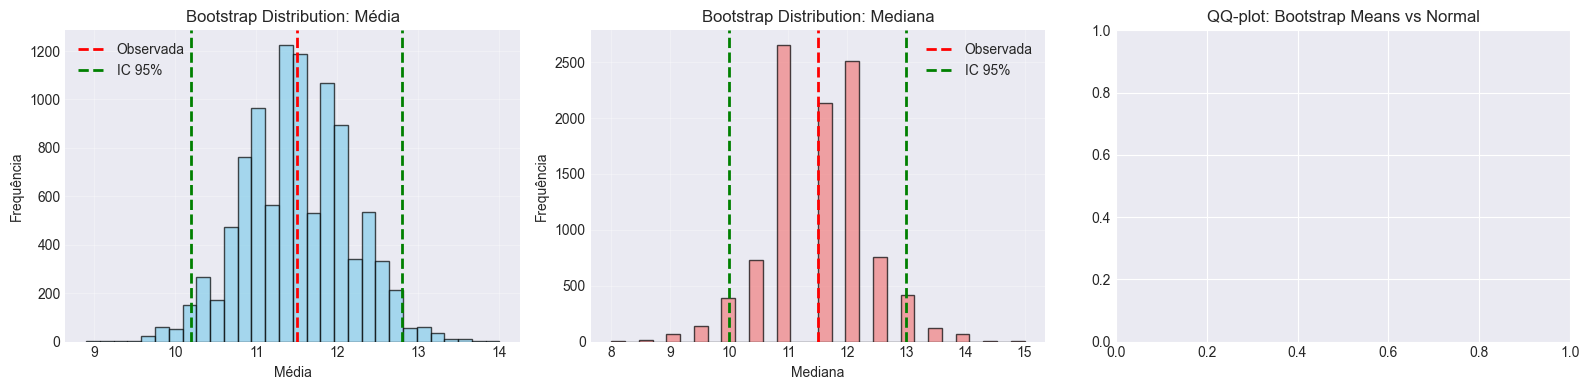

In [8]:
print('=== BOOTSTRAP ===' )
print('Bootstrap: Reamostragem com reposição para estimar distribuições')

# Dados de exemplo
data = np.array([10, 12, 8, 15, 11, 14, 9, 13, 12, 11])
print(f'\nDados: {data}')
print(f'Estatísticas observadas: Média = {data.mean():.2f}, Mediana = {np.median(data):.2f}')

# Bootstrap
np.random.seed(42)
num_bootstrap = 10000
bootstrap_means = []
bootstrap_medians = []

for i in range(num_bootstrap):
    # Reamostragem com reposição
    bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
    bootstrap_means.append(bootstrap_sample.mean())
    bootstrap_medians.append(np.median(bootstrap_sample))

bootstrap_means = np.array(bootstrap_means)
bootstrap_medians = np.array(bootstrap_medians)

# Intervalos de confiança via bootstrap
ci_mean = np.percentile(bootstrap_means, [2.5, 97.5])
ci_median = np.percentile(bootstrap_medians, [2.5, 97.5])

print(f'\n--- Intervalos de Confiança (Bootstrap 95%) ---')
print(f'IC para Média: [{ci_mean[0]:.3f}, {ci_mean[1]:.3f}]')
print(f'IC para Mediana: [{ci_median[0]:.3f}, {ci_median[1]:.3f}]')

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribuição bootstrap da média
axes[0].hist(bootstrap_means, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label='Observada')
axes[0].axvline(ci_mean[0], color='green', linestyle='--', linewidth=2, label='IC 95%')
axes[0].axvline(ci_mean[1], color='green', linestyle='--', linewidth=2)
axes[0].set_xlabel('Média')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Bootstrap Distribution: Média')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribuição bootstrap da mediana
axes[1].hist(bootstrap_medians, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].axvline(np.median(data), color='red', linestyle='--', linewidth=2, label='Observada')
axes[1].axvline(ci_median[0], color='green', linestyle='--', linewidth=2, label='IC 95%')
axes[1].axvline(ci_median[1], color='green', linestyle='--', linewidth=2)
axes[1].set_xlabel('Mediana')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Bootstrap Distribution: Mediana')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# QQ-plot: bootstrap vs normal
# stats.probplot(bootstrap_means, dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot: Bootstrap Means vs Normal')

plt.tight_layout()
plt.show()

### O que observar

- A distribuicao bootstrap da media e aproximadamente Normal (pelo TCL)
- A distribuicao bootstrap da mediana tem formato diferente - nao e Normal!
- O QQ-plot confirma que as medias bootstrap seguem Normal (pontos na linha reta)
- O IC bootstrap para a mediana e mais largo que para a media

### O que concluir

- Bootstrap funciona para QUALQUER estatistica (media, mediana, correlacao, razao, etc.)
- Nao requer pressupostos de distribuicao - e completamente data-driven
- O numero de replicacoes (B=10000) deve ser grande para ICs estaveis
- Bootstrap pode falhar com amostras muito pequenas (n < 10) ou distribuicoes muito pesadas nas caudas
- Para a media, IC bootstrap e IC analitico (t) dao resultados similares; para mediana, bootstrap e a unica opcao facil

### Conexao com outros notebooks

- **0_7 (TCL)**: Bootstrap e uma demonstracao empirica do Teorema Central do Limite
- **1_1 (Descritiva)**: Qualquer estatistica descritiva pode ter seu IC estimado via bootstrap
- **0_8 (Otimizacao)**: Bagging em Random Forests usa bootstrap de amostras para reduzir variancia

## 9. Teste de Correlacao

### Analogia: "Essa Relacao e Real ou Coincidencia?"

No notebook 1_1, voce calculou correlacoes entre variaveis. Mas ver r = 0.3 nao diz se essa correlacao e significativamente diferente de zero. O teste de correlacao formaliza essa pergunta: "dados n pontos e uma correlacao observada r, qual a probabilidade de ver r tao grande se as variaveis fossem realmente independentes?"

### Definicao Formal

- **Pearson**: Testa correlacao linear. t = r * sqrt(n-2) / sqrt(1-r^2), df = n-2. Assume normalidade bivariada.
- **Spearman**: Testa correlacao monotonica (ranks). Nao assume normalidade.
- **IC para r**: Usa transformacao Z de Fisher: Z = 0.5 * ln((1+r)/(1-r)), SE = 1/sqrt(n-3)

### Por que em ML?

Testar significancia de correlacoes e parte da feature selection. Uma feature com correlacao r=0.1 com o target pode nao ser significante (com n=30) ou ser altamente significante (com n=10000). O p-value depende TANTO de r quanto de n. Tambem e usado para detectar multicolinearidade: features altamente correlacionadas entre si podem causar instabilidade em regressao.

In [9]:
# Gerando dados correlacionados
np.random.seed(42)
n = 50
x = np.random.randn(n)
y = 0.7 * x + np.random.randn(n) * 0.5  # Correlação esperada ≈ 0.7

# Correlação de Pearson com teste
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

print('=== TESTE DE CORRELAÇÃO ===' )
print(f'\nDados: n={n} pares')
print(f'\n1. Correlação de Pearson (paramétrica):')
print(f'   r = {pearson_r:.4f}, p-value = {pearson_p:.2e}')
print(f'   Resultado: {"Correlação significante" if pearson_p < 0.05 else "Não significante"}')

print(f'\n2. Correlação de Spearman (não-paramétrica):')
print(f'   ρ = {spearman_rho:.4f}, p-value = {spearman_p:.2e}')
print(f'   Resultado: {"Correlação significante" if spearman_p < 0.05 else "Não significante"}')

# Intervalo de confiança para r (Fisher Z-transformation)
z = 0.5 * np.log((1 + pearson_r) / (1 - pearson_r))  # Fisher Z
se_z = 1 / np.sqrt(n - 3)
ic_z_lower = z - norm.ppf(0.975) * se_z
ic_z_upper = z + norm.ppf(0.975) * se_z

# Transformar de volta para escala r
ic_r_lower = (np.exp(2 * ic_z_lower) - 1) / (np.exp(2 * ic_z_lower) + 1)
ic_r_upper = (np.exp(2 * ic_z_upper) - 1) / (np.exp(2 * ic_z_upper) + 1)

print(f'\nIntervalo de Confiança 95% para r:')
print(f'   IC = [{ic_r_lower:.4f}, {ic_r_upper:.4f}]')

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Scatter plot
axes[0].scatter(x, y, alpha=0.6, s=50)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
axes[0].plot(x, p(x), 'r--', linewidth=2, label=f'Ajuste linear')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title(f'Correlação: r = {pearson_r:.3f}, p = {pearson_p:.2e}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Intervalo de confiança
axes[1].errorbar(['r'], pearson_r, yerr=[[pearson_r - ic_r_lower], [ic_r_upper - pearson_r]], 
                  fmt='o', markersize=10, capsize=10, capthick=2, linewidth=2, color='blue')
axes[1].set_ylabel('Correlação (r)')
axes[1].set_title('Intervalo de Confiança 95% para r')
axes[1].set_ylim(-1, 1)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticklabels(['Pearson r'])

plt.tight_layout()
plt.show()

=== TESTE DE CORRELAÇÃO ===

Dados: n=50 pares

1. Correlação de Pearson (paramétrica):
   r = 0.8502, p-value = 5.65e-15
   Resultado: Correlação significante

2. Correlação de Spearman (não-paramétrica):
   ρ = 0.8409, p-value = 2.16e-14
   Resultado: Correlação significante


NameError: name 'norm' is not defined

### O que observar

- Pearson e Spearman dao resultados similares para relacoes lineares
- O p-value e extremamente pequeno (< 0.001) para r ≈ 0.8 com n=50
- O IC para r via transformacao de Fisher e assimetrico (mais espaco "abaixo" de r do que "acima")
- A linha de ajuste linear no scatter plot confirma a tendencia positiva

### O que concluir

- Correlacao significante nao implica causalidade (mantra da estatistica!)
- Com n grande, ate correlacoes muito pequenas (r=0.05) podem ser significantes - importa o TAMANHO do r, nao so o p-value
- Spearman e mais robusto a outliers e relacoes nao-lineares
- A transformacao de Fisher e necessaria para IC correto porque r e limitado a [-1, +1]

### Conexao com outros notebooks

- **1_1 (Descritiva)**: Correlacao descritiva (r calculado la) agora tem teste formal de significancia
- **1_4 (Regressao)**: R^2 em regressao e r^2 de Pearson para regressao simples
- **0_3 (Algebra Linear)**: Correlacao e o cosseno do angulo entre vetores centrados

## 10. Multiplos Testes e Correcao de Bonferroni

### Analogia: O Problema do "Pescar Significancia"

Imagine que joga uma moeda "justa" uma vez - ha 5% de chance de rejeitar H0 falsamente. Agora jogue 20 vezes. A chance de pelo menos UM falso positivo em 20 testes nao e 5% - e:

P(pelo menos 1 falso positivo) = 1 - (0.95)^20 ≈ 0.64 = 64%

Com 20 testes, voce TEM 64% de chance de encontrar algo "significante" por puro acaso!

### Definicao Formal

**Correcao de Bonferroni**: Divide alpha pelo numero de testes. Para m testes com alpha = 0.05:
alpha_corrigido = 0.05 / m

**Problema**: Bonferroni e MUITO conservador (assume testes independentes). Alternativas menos conservadoras:
- **Holm**: Versao sequencial de Bonferroni (igualmente valida, menos conservadora)
- **FDR (Benjamini-Hochberg)**: Controla a proporcao de falsos positivos entre os rejeitados

### Por que em ML?

Quando voce testa 100 features para selecao, esta fazendo 100 testes. Sem correcao, espera ~5 features "significantes" por acaso. FDR e especialmente popular em ML e genomica porque permite mais descobertas que Bonferroni enquanto controla a taxa de falsas descobertas.

In [10]:
print('=== MULTIPLOS TESTES E CORRECAO ===' )

# Simulação: 20 testes independentes, todos com H0 verdadeira
np.random.seed(42)
num_tests = 20
alpha = 0.05

p_values = []
for i in range(num_tests):
    # Dados de 2 grupos identicos (H0 verdadeira)
    g1 = np.random.normal(100, 15, 30)
    g2 = np.random.normal(100, 15, 30)
    _, p = ttest_ind(g1, g2)
    p_values.append(p)

p_values = np.array(p_values)

print(f'Numero de testes: {num_tests}')
print(f'P-values: {np.round(p_values, 4)}')
print(f'\nSignificantes SEM correcao (p < 0.05): {(p_values < alpha).sum()} de {num_tests}')

# Correcao de Bonferroni
alpha_bonf = alpha / num_tests
print(f'\n--- Correcao de Bonferroni ---')
print(f'Alpha corrigido: {alpha_bonf:.4f}')
print(f'Significantes COM Bonferroni: {(p_values < alpha_bonf).sum()} de {num_tests}')

# FDR (Benjamini-Hochberg) - implementacao manual
sorted_p = np.sort(p_values)
sorted_idx = np.argsort(p_values)
m = len(p_values)
fdr_threshold = np.array([(i+1)/m * alpha for i in range(m)])

# Encontrar o maior i tal que p_(i) <= i/m * alpha
sig_fdr = sorted_p <= fdr_threshold
if sig_fdr.any():
    max_sig = np.where(sig_fdr)[0][-1]
    fdr_count = max_sig + 1
else:
    fdr_count = 0

print(f'\n--- Correcao FDR (Benjamini-Hochberg) ---')
print(f'Significantes COM FDR: {fdr_count} de {num_tests}')

# Simulação de Monte Carlo: probabilidade de falso positivo
print(f'\n--- Simulacao de Monte Carlo ---')
num_sims = 10000
false_positives_none = 0
false_positives_bonf = 0

for _ in range(num_sims):
    ps = []
    for _ in range(num_tests):
        g1 = np.random.normal(100, 15, 30)
        g2 = np.random.normal(100, 15, 30)
        _, p = ttest_ind(g1, g2)
        ps.append(p)
    ps = np.array(ps)

    if (ps < alpha).any():
        false_positives_none += 1
    if (ps < alpha_bonf).any():
        false_positives_bonf += 1

print(f'P(pelo menos 1 falso positivo) SEM correcao:  {false_positives_none/num_sims:.3f}')
print(f'P(pelo menos 1 falso positivo) COM Bonferroni: {false_positives_bonf/num_sims:.3f}')
print(f'Teorico SEM correcao: 1 - (1-alpha)^{num_tests} = {1-(1-alpha)**num_tests:.3f}')

# Visualizacao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# P-values vs thresholds
colors = ['red' if p < alpha else 'blue' for p in sorted_p]
axes[0].bar(range(m), sorted_p, color=colors, alpha=0.7, edgecolor='black')
axes[0].axhline(alpha, color='red', linestyle='--', linewidth=2, label=f'alpha = {alpha}')
axes[0].axhline(alpha_bonf, color='green', linestyle='--', linewidth=2, label=f'Bonferroni = {alpha_bonf:.4f}')
axes[0].plot(range(m), fdr_threshold, 'o-', color='orange', markersize=4, label='FDR threshold')
axes[0].set_xlabel('Teste (ordenado)')
axes[0].set_ylabel('P-value')
axes[0].set_title('P-values vs Thresholds de Correcao')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Probabilidade de falso positivo vs numero de testes
n_tests_range = range(1, 51)
prob_fp = [1 - (1-alpha)**n for n in n_tests_range]
axes[1].plot(n_tests_range, prob_fp, 'r-', linewidth=2, label='Sem correcao')
axes[1].axhline(alpha, color='green', linestyle='--', linewidth=2, label=f'alpha = {alpha}')
axes[1].set_xlabel('Numero de testes')
axes[1].set_ylabel('P(pelo menos 1 falso positivo)')
axes[1].set_title('Inflacao de Erro Tipo I')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== MULTIPLOS TESTES E CORRECAO ===


NameError: name 'ttest_ind' is not defined

### O que observar

- Sem correcao, a probabilidade de pelo menos 1 falso positivo cresce rapidamente com o numero de testes (~64% para 20 testes)
- Bonferroni e muito conservador: alpha vai de 0.05 para 0.0025 com 20 testes
- FDR (Benjamini-Hochberg) tem um threshold que sobe linearmente - e menos conservador
- A simulacao de Monte Carlo confirma os valores teoricos

### O que concluir

- SEMPRE corrija para multiplos testes quando fizer mais de um teste no mesmo estudo
- Bonferroni e seguro mas pode perder efeitos reais (baixo poder); FDR e o compromisso mais popular
- O numero "efetivo" de testes pode ser menor que o numero total se os testes sao correlacionados
- Em ML, isso se aplica a: testar multiplas features, comparar multiplos modelos, otimizar multiplos hiperparametros

### Conexao com outros notebooks

- **0_5 (Probabilidade)**: A formula 1-(1-alpha)^m usa probabilidade do complemento estudada la
- **1_5 (Design de Experimentos)**: Design experimental bem feito minimiza a necessidade de correcoes post-hoc
- **1_3 (Bayesiana)**: Abordagem bayesiana nao sofre com o problema de multiplos testes da mesma forma

## 11. Exercicios Praticos

### Exercicio 1: Teste de Hipotese Completo

Voce coleta dados de uma metrica antes e depois de uma mudanca:
- Antes: [45, 48, 42, 50, 46, 49, 43, 47, 44, 51]
- Depois: [52, 55, 49, 58, 51, 56, 50, 54, 48, 59]

Realize:
1. Teste de normalidade (Shapiro-Wilk) nos dados "antes", "depois" e nas diferencas
2. Teste t pareado
3. Calcule intervalo de confianca para a diferenca
4. Interprete os resultados com effect size (Cohen's d)

In [11]:
# TAREFA DO ALUNO: Exercicio 1 - Teste de Hipotese Completo
before = np.array([45, 48, 42, 50, 46, 49, 43, 47, 44, 51])
after = np.array([52, 55, 49, 58, 51, 56, 50, 54, 48, 59])

# 1. Teste de normalidade (Shapiro-Wilk) para antes, depois e diferencas
# stat_before, p_before = None  # TAREFA DO ALUNO
# stat_after, p_after = None  # TAREFA DO ALUNO
# stat_diff, p_diff = None  # TAREFA DO ALUNO

# 2. Teste t pareado
# t_stat, p_value = None  # TAREFA DO ALUNO

# 3. Intervalo de confianca para a diferenca
# diff = None  # TAREFA DO ALUNO
# se_diff = None  # TAREFA DO ALUNO
# ic_lower = None  # TAREFA DO ALUNO
# ic_upper = None  # TAREFA DO ALUNO

# 4. Effect size (Cohen's d = media_diff / std_diff)
# cohens_d = None  # TAREFA DO ALUNO

# Imprima todos os resultados

In [12]:
# SOLUCAO - Exercicio 1
before = np.array([45, 48, 42, 50, 46, 49, 43, 47, 44, 51])
after = np.array([52, 55, 49, 58, 51, 56, 50, 54, 48, 59])
diff = after - before

print('=== EXERCICIO 1: TESTE DE HIPOTESE COMPLETO ===')

# 1. Normalidade
print('\n1. Teste de Normalidade (Shapiro-Wilk):')
for name, data in [('Antes', before), ('Depois', after), ('Diferenca', diff)]:
    stat, p = stats.shapiro(data)
    print(f'   {name}: W={stat:.4f}, p-value={p:.4f} -> {"Normal" if p > 0.05 else "Nao normal"}')

# 2. Teste t pareado
t_stat, p_value = stats.ttest_rel(before, after)
print(f'\n2. Teste t Pareado:')
print(f'   Diferenca media: {diff.mean():.2f}')
print(f'   t-statistic = {t_stat:.4f}')
print(f'   p-value = {p_value:.6f}')
print(f'   Conclusao: {"Mudanca significante" if p_value < 0.05 else "Sem mudanca significante"}')

# 3. IC para diferenca
se_diff = diff.std(ddof=1) / np.sqrt(len(diff))
t_crit = t_dist.ppf(0.975, len(diff) - 1)
ic_lower = diff.mean() - t_crit * se_diff
ic_upper = diff.mean() + t_crit * se_diff
print(f'\n3. Intervalo de Confianca 95%:')
print(f'   IC = [{ic_lower:.2f}, {ic_upper:.2f}]')

# 4. Effect size
cohens_d = diff.mean() / diff.std(ddof=1)
print(f'\n4. Effect Size:')
print(f'   Cohen\'s d = {cohens_d:.2f}')
magnitude = 'pequeno' if abs(cohens_d) < 0.5 else ('medio' if abs(cohens_d) < 0.8 else 'grande')
print(f'   Magnitude: {magnitude} (|d|<0.5=pequeno, 0.5-0.8=medio, >0.8=grande)')

print(f'\n5. Interpretacao:')
print(f'   Houve aumento medio de {diff.mean():.1f} unidades (IC 95%: [{ic_lower:.1f}, {ic_upper:.1f}])')
print(f'   Diferenca estatisticamente significante (p = {p_value:.6f})')
print(f'   Efeito {magnitude} (d = {cohens_d:.2f})')

=== EXERCICIO 1: TESTE DE HIPOTESE COMPLETO ===

1. Teste de Normalidade (Shapiro-Wilk):


NameError: name 'stats' is not defined

### Exercicio 2: A/B Test Manual

Dados de um A/B test para taxa de cliques em um anuncio:
- Grupo A (Controle): 1000 impressoes, 80 cliques
- Grupo B (Tratamento): 1000 impressoes, 110 cliques

Realize o teste SEM usar statsmodels (calcule manualmente):
1. Calcule as taxas de conversao e o lift
2. Calcule o erro padrao da diferenca
3. Calcule a estatistica Z e o p-value
4. Construa o IC 95% para a diferenca de proporcoes

In [13]:
# TAREFA DO ALUNO: Exercicio 2 - A/B Test Manual
n_a = 1000
clicks_a = 80
n_b = 1000
clicks_b = 110

# 1. Taxas de conversao e lift
# ctr_a = None  # TAREFA DO ALUNO
# ctr_b = None  # TAREFA DO ALUNO
# lift = None  # TAREFA DO ALUNO (em percentual)

# 2. Erro padrao da diferenca
# se_a = None  # TAREFA DO ALUNO: sqrt(p*(1-p)/n) para cada grupo
# se_b = None  # TAREFA DO ALUNO
# se_diff = None  # TAREFA DO ALUNO: sqrt(se_a^2 + se_b^2)

# 3. Estatistica Z e p-value
# z_stat = None  # TAREFA DO ALUNO: (ctr_b - ctr_a) / se_diff
# p_value = None  # TAREFA DO ALUNO: 2 * (1 - norm.cdf(abs(z_stat)))

# 4. IC 95% para diferenca
# diff = None  # TAREFA DO ALUNO
# ic_lower = None  # TAREFA DO ALUNO
# ic_upper = None  # TAREFA DO ALUNO

# Imprima resultados

In [14]:
# SOLUCAO - Exercicio 2
n_a = 1000
clicks_a = 80
n_b = 1000
clicks_b = 110

print('=== EXERCICIO 2: A/B TEST MANUAL ===')

# 1. Taxas e lift
ctr_a = clicks_a / n_a
ctr_b = clicks_b / n_b
lift = (ctr_b / ctr_a - 1) * 100

print(f'\n1. Taxas de Conversao:')
print(f'   CTR Controle: {ctr_a:.1%}')
print(f'   CTR Tratamento: {ctr_b:.1%}')
print(f'   Lift: {lift:.1f}%')

# 2. Erro padrao
se_a = np.sqrt(ctr_a * (1 - ctr_a) / n_a)
se_b = np.sqrt(ctr_b * (1 - ctr_b) / n_b)
se_diff = np.sqrt(se_a**2 + se_b**2)

print(f'\n2. Erro Padrao:')
print(f'   SE(A) = {se_a:.5f}')
print(f'   SE(B) = {se_b:.5f}')
print(f'   SE(diff) = {se_diff:.5f}')

# 3. Z e p-value
diff = ctr_b - ctr_a
z_stat = diff / se_diff
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print(f'\n3. Teste de Hipotese:')
print(f'   Z-statistic = {z_stat:.4f}')
print(f'   P-value = {p_value:.4f}')
print(f'   Resultado: {"Diferenca significante" if p_value < 0.05 else "Sem diferenca significante"}')

# 4. IC 95%
z_crit = norm.ppf(0.975)
ic_lower = diff - z_crit * se_diff
ic_upper = diff + z_crit * se_diff

print(f'\n4. IC 95% para diferenca:')
print(f'   Diferenca: {diff:.4f} ({diff*100:.2f}%)')
print(f'   IC = [{ic_lower:.4f}, {ic_upper:.4f}]')
print(f'   IC contem zero? {"Sim (nao significante)" if ic_lower <= 0 <= ic_upper else "Nao (significante)"}')

=== EXERCICIO 2: A/B TEST MANUAL ===

1. Taxas de Conversao:
   CTR Controle: 8.0%
   CTR Tratamento: 11.0%
   Lift: 37.5%

2. Erro Padrao:
   SE(A) = 0.00858
   SE(B) = 0.00989
   SE(diff) = 0.01310


NameError: name 'norm' is not defined

### Exercicio 3: Bootstrap vs Analitico

Use os dados abaixo para comparar IC analitico (t) e IC bootstrap para a media:
`dados = [12, 15, 11, 18, 14, 20, 10, 17, 13, 19, 16, 21]`

1. Calcule o IC analitico (usando distribuicao t)
2. Calcule o IC bootstrap (10000 replicacoes)
3. Compare os dois ICs e discuta quando cada metodo e preferivel

In [15]:
# TAREFA DO ALUNO: Exercicio 3 - Bootstrap vs Analitico
dados = np.array([12, 15, 11, 18, 14, 20, 10, 17, 13, 19, 16, 21])

# 1. IC analitico (distribuicao t)
# n = None  # TAREFA DO ALUNO
# x_bar = None  # TAREFA DO ALUNO
# s = None  # TAREFA DO ALUNO (ddof=1)
# se = None  # TAREFA DO ALUNO
# t_crit = None  # TAREFA DO ALUNO: t_dist.ppf(0.975, n-1)
# ic_analitico = None  # TAREFA DO ALUNO: [x_bar - t_crit*se, x_bar + t_crit*se]

# 2. IC bootstrap
# np.random.seed(42)
# bootstrap_means = []
# for _ in range(10000):
#     TAREFA DO ALUNO: reamostrar com reposicao e calcular media
#     pass
# ic_bootstrap = None  # TAREFA DO ALUNO: percentis 2.5% e 97.5%

# 3. Comparar e imprimir resultados

In [16]:
# SOLUCAO - Exercicio 3
dados = np.array([12, 15, 11, 18, 14, 20, 10, 17, 13, 19, 16, 21])

print('=== EXERCICIO 3: BOOTSTRAP VS ANALITICO ===')
print(f'Dados: {dados}')
print(f'Media: {dados.mean():.2f}, Mediana: {np.median(dados):.2f}, s: {dados.std(ddof=1):.2f}')

# 1. IC analitico
n = len(dados)
x_bar = dados.mean()
s = dados.std(ddof=1)
se = s / np.sqrt(n)
t_crit = t_ppf(0.975, n-1)
ic_analitico = [x_bar - t_crit * se, x_bar + t_crit * se]

print(f'\n1. IC Analitico (distribuicao t):')
print(f'   SE = {se:.3f}, t_crit(df={n-1}) = {t_crit:.3f}')
print(f'   IC 95% = [{ic_analitico[0]:.2f}, {ic_analitico[1]:.2f}]')

# 2. IC bootstrap
np.random.seed(42)
bootstrap_means = []
for _ in range(10000):
    boot_sample = np.random.choice(dados, size=n, replace=True)
    bootstrap_means.append(boot_sample.mean())
bootstrap_means = np.array(bootstrap_means)
ic_bootstrap = np.percentile(bootstrap_means, [2.5, 97.5])

print(f'\n2. IC Bootstrap (10000 replicacoes):')
print(f'   SE bootstrap = {bootstrap_means.std():.3f}')
print(f'   IC 95% = [{ic_bootstrap[0]:.2f}, {ic_bootstrap[1]:.2f}]')

# 3. Comparacao
print(f'\n3. Comparacao:')
print(f'   Analitico:  [{ic_analitico[0]:.2f}, {ic_analitico[1]:.2f}] (largura: {ic_analitico[1]-ic_analitico[0]:.2f})')
print(f'   Bootstrap:  [{ic_bootstrap[0]:.2f}, {ic_bootstrap[1]:.2f}] (largura: {ic_bootstrap[1]-ic_bootstrap[0]:.2f})')
print(f'   Diferenca entre metodos: pequena')
print(f'\n   Quando preferir cada um:')
print(f'   - Analitico: dados aproximadamente normais, amostra razoavel (n >= 20)')
print(f'   - Bootstrap: distribuicao desconhecida, amostras pequenas, ou estatisticas complexas (mediana, razao)')

=== EXERCICIO 3: BOOTSTRAP VS ANALITICO ===
Dados: [12 15 11 18 14 20 10 17 13 19 16 21]
Media: 15.50, Mediana: 15.50, s: 3.61


NameError: name 't_ppf' is not defined

## 12. Erros Comuns e Armadilhas

### Erro 1: Interpretar p-value como probabilidade de H0

**Errado**: "p = 0.03 significa 3% de chance de H0 ser verdadeira"
**Correto**: "Se H0 fosse verdadeira, haveria 3% de chance de ver dados tao extremos"
Essa distincao e sutil mas fundamental. O p-value e sobre os DADOS dado H0, nao sobre H0 dados os dados.

### Erro 2: HARKing (Hypothesis After Results are Known)

**Errado**: Testar 20 variaveis, encontrar uma significante (p < 0.05), e dizer "essa era minha hipotese!"
**Correto**: Pre-registrar hipoteses ANTES de olhar os dados. Analises exploratorias devem ser rotuladas como tal.

### Erro 3: Nao ajustar para multiplos testes

**Errado**: Testar 100 features com alpha = 0.05 e reportar as 5 "significantes"
**Correto**: Ajustar com Bonferroni ou FDR. Sem correcao, ~5 falsos positivos sao esperados por acaso.

### Erro 4: Confundir significancia estatistica com pratica

**Errado**: "p < 0.05, logo o efeito e importante"
**Correto**: Com n = 100000, um efeito minusculo (0.01% de diferenca) pode ser significante. Sempre reporte effect size (Cohen's d, r, odds ratio) junto com p-value.

### Erro 5: Ignorar poder estatistico

**Errado**: "p > 0.05, logo nao ha efeito"
**Correto**: Se o teste tem poder baixo (n pequeno), voce pode estar PERDENDO um efeito real (erro tipo II). Calcule poder a priori.

### Erro 6: Violacoes de pressupostos

**Errado**: Usar teste t em dados altamente nao-normais ou com variancias desiguais
**Correto**: Verificar pressupostos (Shapiro-Wilk, Levene) e usar alternativas robustas quando necessario (Mann-Whitney, Welch t-test, bootstrap).

### Erro 7: Confundir correlacao com causalidade

**Errado**: "X e Y sao correlacionados, logo X causa Y"
**Correto**: Correlacao pode surgir de: X causa Y, Y causa X, Z causa ambos, ou coincidencia. So experimentos controlados (A/B testing) estabelecem causalidade.

## 13. Resumo e Conexoes

### Hierarquia dos Conceitos

```
POPULACAO (desconhecida)
    |
    | (amostragem aleatoria)
    v
AMOSTRA (coletada)
    |
    |---> Estatistica Descritiva (media, s, proporcao)
    |
    v
DISTRIBUICAO AMOSTRAL (teorica, via TCL)
    |
    |---> Intervalo de Confianca (onde esta o parametro?)
    |---> Teste de Hipotese (H0 e improvavel?)
    |---> P-value (quao extremos sao meus dados sob H0?)
    |
    v
DECISAO + INTERPRETACAO
    |
    |---> Se significante: considere effect size e relevancia pratica
    |---> Se nao significante: considere poder estatistico (n suficiente?)
    |---> Sempre: corrija para multiplos testes se aplicavel
```

### Guia de Escolha do Teste

| Situacao | Teste | Secao |
|----------|-------|-------|
| 1 amostra vs valor teorico | t de uma amostra | 4 |
| 2 grupos independentes | t independente | 4 |
| 2 medicoes pareadas | t pareado | 4 |
| 3+ grupos | ANOVA (+ Tukey post-hoc) | 6 |
| 2 variaveis categoricas | Qui-quadrado | 5 |
| Proporcoes (A/B test) | Teste Z de proporcoes | 7 |
| Correlacao linear | Pearson + teste t | 9 |
| Correlacao monotonica | Spearman | 9 |
| IC sem pressupostos | Bootstrap | 8 |
| Multiplos testes | Bonferroni / FDR | 10 |

### Tabela de Conexoes

| Conceito deste notebook | Conecta com | Como |
|------------------------|-------------|------|
| Distribuicao amostral | 0_7 (TCL) | TCL fundamenta por que medias amostrais sao normais |
| P-value | 0_5 (Probabilidade) | P-value e probabilidade condicional P(dados | H0) |
| Distribuicao t, F, chi2 | 0_6 (Distribuicoes) | Distribuicoes de referencia para os testes |
| Media, desvio padrao | 1_1 (Descritiva) | Estatisticas descritivas alimentam os testes |
| Teste t em regressao | 1_4 (Regressao) | Coeficientes testados com teste t |
| Design experimental | 1_5 (Design) | Framework H0/H1 + ANOVA para experimentos |
| A/B testing bayesiano | 1_3 (Bayesiana) | Alternativa ao framework frequentista |
| Bootstrap / Bagging | 0_8 (Otimizacao) | Bootstrap aplicado a modelos (Random Forest) |

### Checklist de Competencias

- [ ] Sei calcular e interpretar intervalos de confianca para medias e proporcoes
- [ ] Sei formular H0 e H1 corretamente para diferentes situacoes
- [ ] Sei interpretar p-values sem cometer os erros classicos
- [ ] Sei escolher o teste correto (t, qui-quadrado, ANOVA, etc.)
- [ ] Sei realizar A/B test completo com calculo de tamanho amostral
- [ ] Sei usar bootstrap quando pressupostos parametricos falham
- [ ] Sei corrigir para multiplos testes (Bonferroni, FDR)
- [ ] Sei reportar effect size junto com p-value

### Proximos Passos

No notebook **1_3 (Estatistica Bayesiana)**, voce aprendera uma ALTERNATIVA ao framework frequentista visto aqui. Em vez de p-values e rejeicao de H0, a abordagem bayesiana atualiza probabilidades diretamente sobre hipoteses usando o Teorema de Bayes. Isso resolve varios dos problemas discutidos aqui (multiplos testes, interpretacao de p-values).